**Articles of the week:**

The first group will read these two articles and create a short 10 min presentation. Everybody else has to also read the articles and prepare to understand the presentation better. 
- https://www.sciencedirect.com/science/article/pii/S0034425717302900
- https://www.scup.com/doi/10.18261/issn.2535-6003-2021-03-04-09


# **A taste of remote sensing big data**

**Import necessary packages**

In [9]:
%matplotlib inline
import os, glob, pathlib

import rioxarray
import numpy as np
import pandas as pd
import xarray as xr

from osgeo import gdal
from osgeo import gdal_array

import seaborn as sns
import matplotlib.pyplot as plt

**Find and list all VRT file(s) in directory**

In [10]:
# Directory where your image data are stored. Replace with your path
directory_path = "C:/Users/celtvete/OneDrive - Norwegian University of Life Sciences/GMFM350/programming/data/T32VNM_20220517T103631"

DIR_PATH = pathlib.Path().resolve()
DATA_PATH = DIR_PATH / "data"

In [11]:
os.getcwd()

'/Users/simenkrogstie/Documents/Programming/H26/GMFM350/notebooks/assignment_2'

In [12]:
vrt_files = glob.glob(os.path.join(DIR_PATH / "data",'*.vrt'))
vrt_files

['/Users/simenkrogstie/Documents/Programming/H26/GMFM350/notebooks/assignment_2/data/T32VNM_20220517T103631.vrt']

--------------------
**The Xarray Python package**


As you may have experienced, depending on the capacity of your PC, the file could not be read due to memory limitation. A big data solution is therefore needed. One such solution is using **xarray** (https://docs.xarray.dev/en/stable/index.html). Xarray is an open source project and Python package that introduces labels in the form of dimensions, coordinates, and attributes on top of raw NumPy-like arrays, which allows for more intuitive, more concise, and less error-prone user experience.

Xarray enables lazy (delayed) and chunked reading in addition to vectorized operation, metadata tracking, group-by operations, operations over named dimensions, selection by label and flexible and extensible I/O backend API. The coordinates, dimensions and variables are all labled in xarray (as shown in the example figure) making them easy to access.
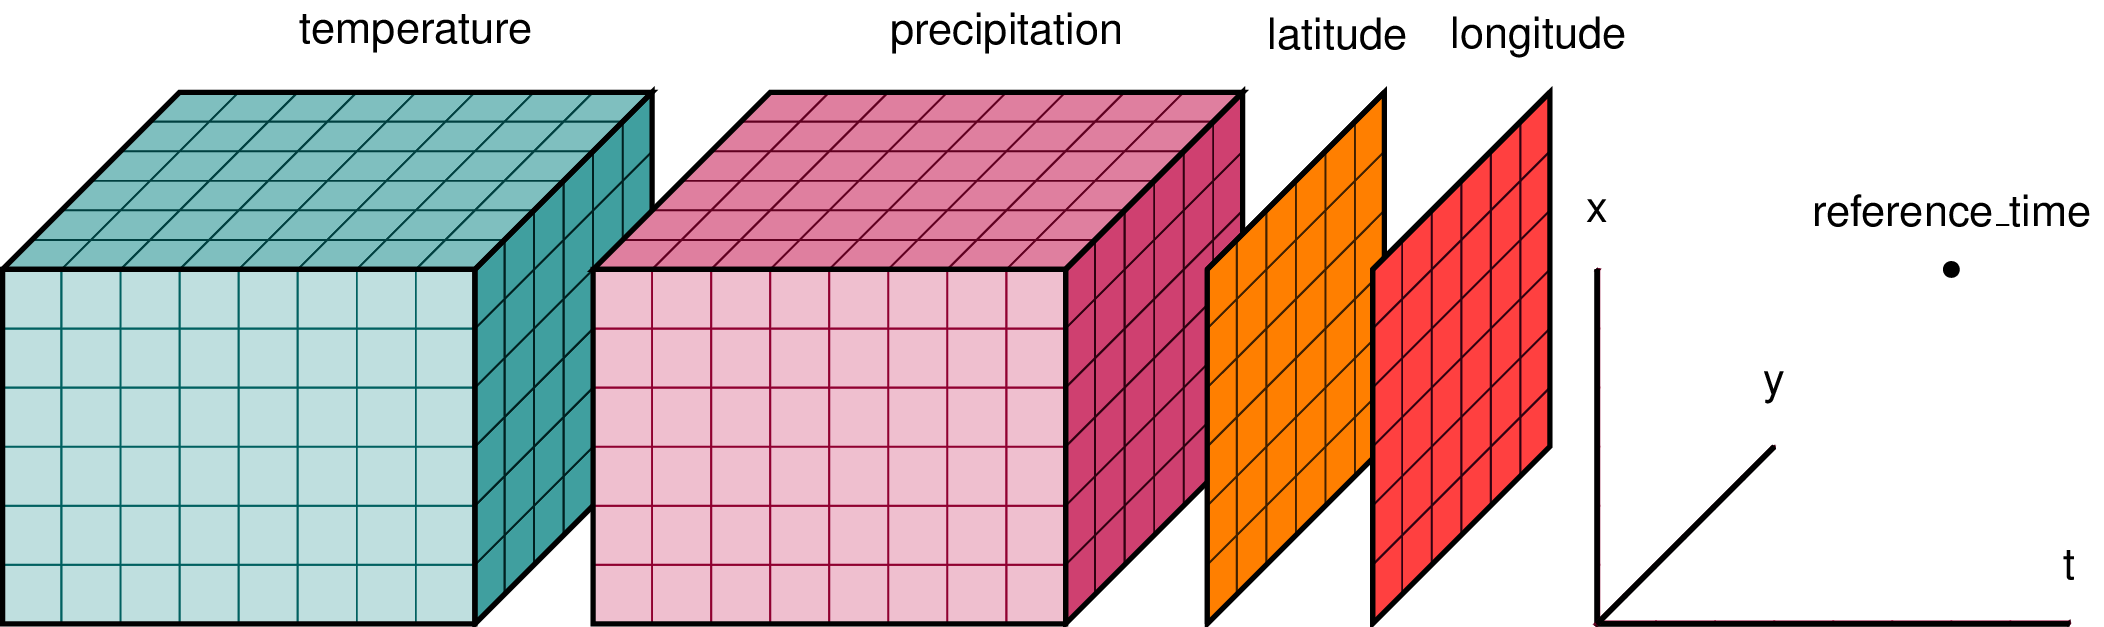
Let's try it!

-------------------
**Read the large image file as a dataset**

The image created from buildvrt has 11 spectral bands at 10m spatial resolution. The data type is floating point making it even larger than it would have been if it were in integer format.

In [13]:
# Select vrt file to work with
data = xr.open_dataset(vrt_files[0])

**Explore the dataset**

We can see information related to the dimesnions (bands, x, y) and spatial referance system of the image

In [14]:
data

<xarray.Dataset> Size: 5GB
Dimensions:      (band: 11, x: 10980, y: 10980)
Coordinates:
  * band         (band) int64 88B 1 2 3 4 5 6 7 8 9 10 11
  * x            (x) float64 88kB 5e+05 5e+05 5e+05 ... 6.098e+05 6.098e+05
  * y            (y) float64 88kB 6.7e+06 6.7e+06 6.7e+06 ... 6.59e+06 6.59e+06
    spatial_ref  int64 8B ...
Data variables:
    band_data    (band, y, x) float32 5GB ...

In [15]:
# The dimensions of the dataset - a dictionary that maps dimension names to their fixed integer lengths
data.dims

FrozenMappingWarningOnValuesAccess({'band': 11, 'x': 10980, 'y': 10980})

In [16]:
# The coordinates of the data - a container holding coordinate arrays used to label points along each dimension
data.coords

Coordinates:
  * band         (band) int64 88B 1 2 3 4 5 6 7 8 9 10 11
  * x            (x) float64 88kB 5e+05 5e+05 5e+05 ... 6.098e+05 6.098e+05
  * y            (y) float64 88kB 6.7e+06 6.7e+06 6.7e+06 ... 6.59e+06 6.59e+06
    spatial_ref  int64 8B ...

In [17]:
# Command to see information about the variables associated with the dataset
data.variables

Frozen({'band': <xarray.IndexVariable 'band' (band: 11)> Size: 88B
array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11]), 'x': <xarray.IndexVariable 'x' (x: 10980)> Size: 88kB
array([499985., 499995., 500005., ..., 609755., 609765., 609775.],
      shape=(10980,)), 'y': <xarray.IndexVariable 'y' (y: 10980)> Size: 88kB
array([6700015., 6700005., 6699995., ..., 6590245., 6590235., 6590225.],
      shape=(10980,)), 'spatial_ref': <xarray.Variable ()> Size: 8B
[1 values with dtype=int64]
Attributes: (12/18)
    crs_wkt:                           PROJCS["WGS 84 / UTM zone 32N",GEOGCS[...
    semi_major_axis:                   6378137.0
    semi_minor_axis:                   6356752.314245179
    inverse_flattening:                298.257223563
    reference_ellipsoid_name:          WGS 84
    longitude_of_prime_meridian:       0.0
    ...                                ...
    longitude_of_central_meridian:     9.0
    false_easting:                     500000.0
    false_northing:           

Varibales contain dataarrays among others. Dataarrays are N-dimensional numerical data such as images. 'band_data' is the default name for image data read typically from tif, jp2, and similar file formats.

In [18]:
# Compute the mean value across all dimensions (bands, rows, and cols) of the image
data['band_data'].mean()

<xarray.DataArray 'band_data' ()> Size: 4B
array(2113.8513, dtype=float32)
Coordinates:
    spatial_ref  int64 8B ...

**Slicing the data**

We can now slice the dataarray as we wish and read to memory, explore or analyse it.

In [19]:
da = data['band_data']

# Keeping all bands and a 500 pixels interval for y and x
da_slice = da[:, 5000:5500, 5000:5500]
da_slice

<xarray.DataArray 'band_data' (band: 11, y: 500, x: 500)> Size: 11MB
array([[[4452., 4464., ..., 3885., 4583.],
        [4532., 4576., ..., 3956., 4331.],
        ...,
        [4596., 4413., ..., 1013., 1005.],
        [4086., 3820., ..., 1010., 1002.]],

       [[4537., 4537., ..., 4454., 4454.],
        [4537., 4537., ..., 4454., 4454.],
        ...,
        [4129., 4129., ...,  993.,  993.],
        [4129., 4129., ...,  993.,  993.]],

       ...,

       [[3812., 3812., ..., 3763., 3763.],
        [3812., 3812., ..., 3763., 3763.],
        ...,
        [3426., 3426., ...,  987.,  987.],
        [3426., 3426., ...,  987.,  987.]],

       [[2457., 2457., ..., 2990., 2990.],
        [2457., 2457., ..., 2990., 2990.],
        ...,
        [2004., 2004., ..., 1042., 1042.],
        [2004., 2004., ..., 1042., 1042.]]],
      shape=(11, 500, 500), dtype=float32)
Coordinates:
  * band         (band) int64 88B 1 2 3 4 5 6 7 8 9 10 11
  * y            (y) float64 4kB 6.65e+06 6.65e+06 ... 6.645e+06 6.645e+06
  * x            (x) float64 4kB 5.5e+05 5.5e+05 5.5e+05 ... 5.55e+05 5.55e+05
    spatial_ref  int64 8B ...

So far, the data has only been lazy loaded, meaning that none of the data has been read into memory. In order to analyse or plot it, the data needs to be loaded to memory as a dataarray.

In [20]:
# Loading the data to memory
da_slice.load()

<xarray.DataArray 'band_data' (band: 11, y: 500, x: 500)> Size: 11MB
array([[[4452., 4464., 4565., ..., 4824., 3885., 4583.],
        [4532., 4576., 4692., ..., 3651., 3956., 4331.],
        [4573., 4596., 4664., ..., 3830., 4501., 4177.],
        ...,
        [4476., 4089., 3407., ..., 1013., 1006., 1002.],
        [4596., 4413., 3544., ..., 1019., 1013., 1005.],
        [4086., 3820., 3371., ..., 1013., 1010., 1002.]],

       [[4537., 4537., 4696., ..., 4304., 4454., 4454.],
        [4537., 4537., 4696., ..., 4304., 4454., 4454.],
        [4581., 4581., 4607., ..., 4183., 4356., 4356.],
        ...,
        [4229., 4229., 3666., ..., 1001.,  982.,  982.],
        [4129., 4129., 3417., ...,  992.,  993.,  993.],
        [4129., 4129., 3417., ...,  992.,  993.,  993.]],

       [[1439., 1446., 1394., ..., 1445., 1906., 1804.],
        [1453., 1433., 1407., ..., 1241., 1617., 1769.],
        [1439., 1404., 1400., ..., 1217., 1489., 1708.],
        ...,
...
        [3963., 3963., 3296., ..., 1001., 1006., 1006.],
        [3795., 3795., 3190., ..., 1018., 1002., 1002.],
        [3795., 3795., 3190., ..., 1018., 1002., 1002.]],

       [[3812., 3812., 3896., ..., 3665., 3763., 3763.],
        [3812., 3812., 3896., ..., 3665., 3763., 3763.],
        [3793., 3793., 3841., ..., 3494., 3645., 3645.],
        ...,
        [3512., 3512., 2916., ..., 1000.,  990.,  990.],
        [3426., 3426., 3039., ..., 1006.,  987.,  987.],
        [3426., 3426., 3039., ..., 1006.,  987.,  987.]],

       [[2457., 2457., 2352., ..., 2515., 2990., 2990.],
        [2457., 2457., 2352., ..., 2515., 2990., 2990.],
        [2428., 2428., 2320., ..., 2325., 2663., 2663.],
        ...,
        [2033., 2033., 2061., ..., 1050., 1042., 1042.],
        [2004., 2004., 2087., ..., 1043., 1042., 1042.],
        [2004., 2004., 2087., ..., 1043., 1042., 1042.]]],
      shape=(11, 500, 500), dtype=float32)
Coordinates:
  * band         (band) int64 88B 1 2 3 4 5 6 7 8 9 10 11
  * y            (y) float64 4kB 6.65e+06 6.65e+06 ... 6.645e+06 6.645e+06
  * x            (x) float64 4kB 5.5e+05 5.5e+05 5.5e+05 ... 5.55e+05 5.55e+05
    spatial_ref  int64 8B 0

In [21]:
# Reshape the xarray to be 2-dimensional: (bands, y, x) -> (bands, n_pixels) 
# and transpose the values: (bands, n_pixels) -> (n_pixels, bands)
data = da_slice.data.reshape((da_slice.shape[0], da_slice.shape[1] * da_slice.shape[2])).transpose()
print("Shape of data:", data.shape)

# Store the data as a DataFrame
data = pd.DataFrame(data)

Shape of data: (250000, 11)


In [22]:
# Compute the correlation between the bands
corr = data.corr(numeric_only=True)
corr

# Plot correlation heatmap
#sns.heatmap(corr, cmap="YlGnBu", annot=True)

,0,1,2,3,4,5,6,7,8,9,10
0,1.000000,0.959491,0.270886,0.377723,0.283031,0.270886,0.571922,0.491932,0.958796,0.943125,0.371670
1,0.959491,1.000000,0.250005,0.350967,0.264380,0.250005,0.589820,0.494799,0.992481,0.973295,0.372116
2,0.270886,0.250005,1.000000,0.988887,0.985944,1.000000,0.794599,0.925611,0.304357,0.430534,0.910583
3,0.377723,0.350967,0.988887,1.000000,0.985392,0.988887,0.838680,0.955125,0.402720,0.524959,0.927571
4,0.283031,0.264380,0.985944,0.985392,1.000000,0.985944,0.841877,0.945766,0.311963,0.439236,0.945076
5,0.270886,0.250005,1.000000,0.988887,0.985944,1.000000,0.794599,0.925611,0.304357,0.430534,0.910583
6,0.571922,0.589820,0.794599,0.838680,0.841877,0.794599,1.000000,0.935372,0.602975,0.698243,0.941290
7,0.491932,0.494799,0.925611,0.955125,0.945766,0.925611,0.935372,1.000000,0.534310,0.650190,0.964902
8,0.958796,0.992481,0.304357,0.402720,0.311963,0.304357,0.602975,0.534310,1.000000,0.984666,0.407728
9,0.943125,0.973295,0.430534,0.524959,0.439236,0.430534,0.698243,0.650190,0.984666,1.000000,0.527146


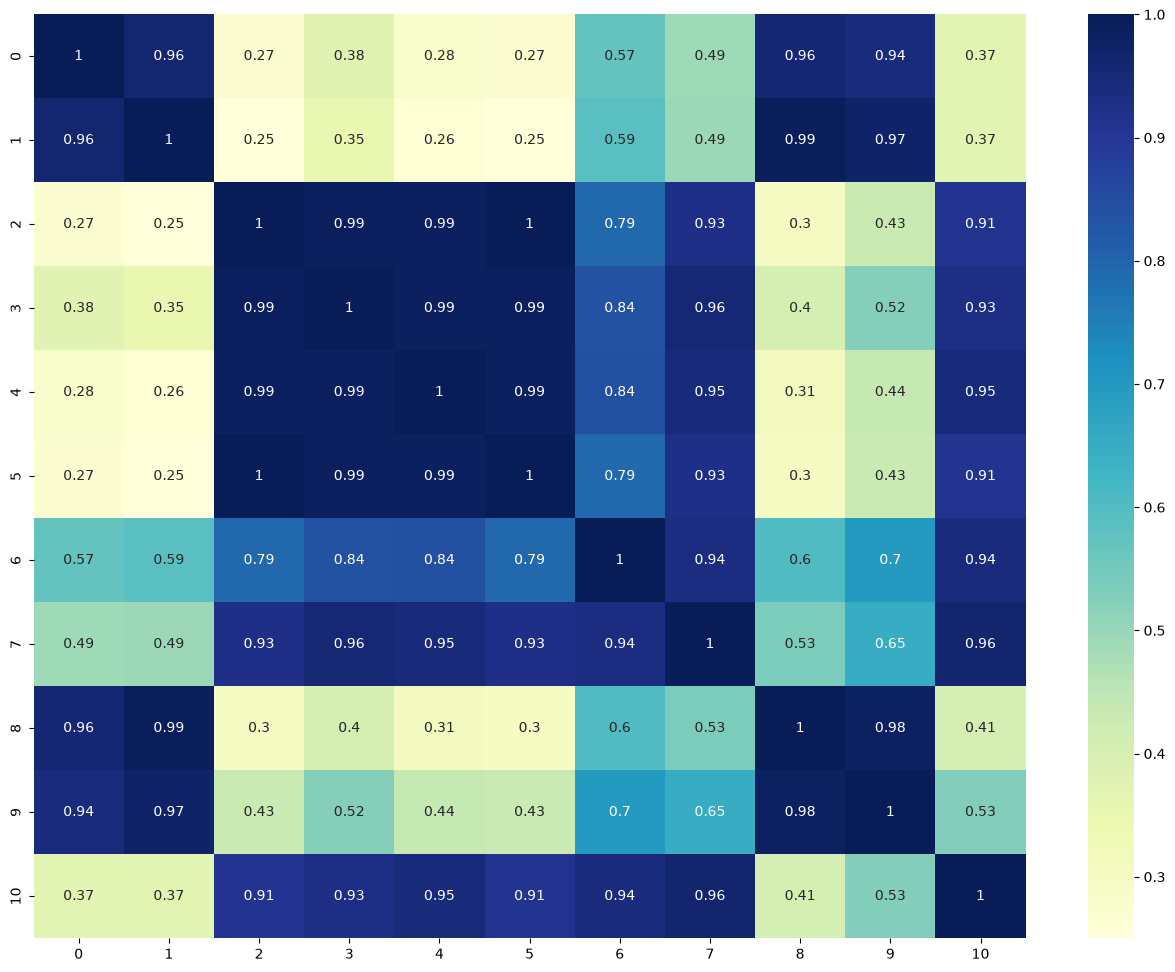

In [23]:
# Set figure size ((width, height) in inches)
plt.figure(figsize=(16, 12))
# Plot correlation heatmap
sns.heatmap(corr, cmap="YlGnBu", annot=True)

# Display heatmap
plt.show()

**Image statistics**

Statistics can now be computed for any of the dimensions, a very useful capability.

In [24]:
# Mean values along the dimension of the bands. The output for each pixel is the mean value of all the 11 bands.
da_slice.mean(dim='band')

<xarray.DataArray 'band_data' (y: 500, x: 500)> Size: 1MB
array([[2899.6365 , 2894.5454 , 2903.6365 , ..., 2855.4546 , 3068.9092 ,
        3089.2727 ],
       [2907.4546 , 2905.0908 , 2917.818  , ..., 2660.9092 , 2976.     ,
        3064.     ],
       [2900.2727 , 2893.0908 , 2875.5454 , ..., 2583.818  , 2895.2727 ,
        2942.4546 ],
       ...,
       [2660.9092 , 2585.2727 , 2293.7273 , ..., 1019.63635, 1010.5455 ,
        1005.5455 ],
       [2651.3635 , 2607.2727 , 2304.3635 , ..., 1018.5455 , 1013.2727 ,
        1012.5455 ],
       [2574.818  , 2541.4546 , 2291.5454 , ..., 1015.4545 , 1011.2727 ,
        1010.     ]], shape=(500, 500), dtype=float32)
Coordinates:
  * y            (y) float64 4kB 6.65e+06 6.65e+06 ... 6.645e+06 6.645e+06
  * x            (x) float64 4kB 5.5e+05 5.5e+05 5.5e+05 ... 5.55e+05 5.55e+05
    spatial_ref  int64 8B 0

**Visualization**

The slice can be visualized by choosing three bands and rescaling to either 0 to 1  (float) or 0 to 255 (integer).

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.4176].


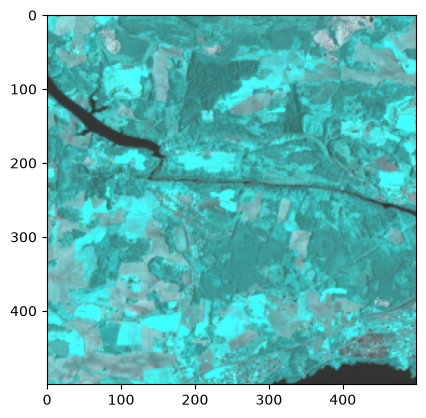

In [25]:
# Plot the image as a RGB image (red is index 2, green index 1 and blue index 0)
plt.imshow(da_slice.data[[2, 1, 0],:,:].transpose()/5000)

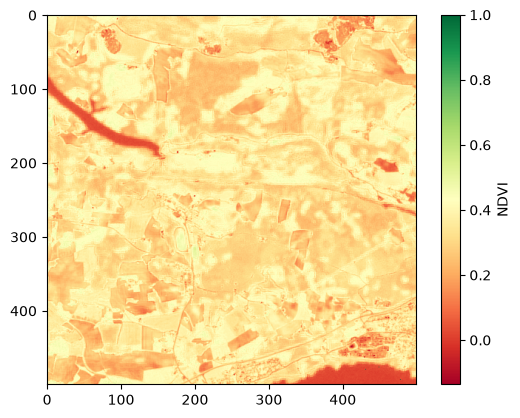

In [26]:
# Calculating Normalized Difference Vegeation Index: NDVI = (NIR - R) / (NIR + R)
NDVI = (da_slice[6] - da_slice[2]) / (da_slice[6] + da_slice[2])
# NDVI.min(), NDVI.max()

# Healthy vegetation is visualized in green
plt.imshow(NDVI.transpose(), cmap='RdYlGn')
plt.colorbar(label="NDVI")

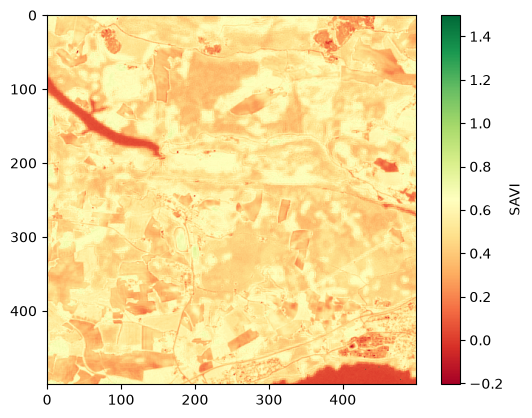

In [27]:
# Calculating Soil Adjusted Vegeation Index: SAVI = ((NIR - R) / (NIR + R + L)) * (1 + L)
L = 0.5
SAVI = ((da_slice[6] - da_slice[2]) / (da_slice[6] + da_slice[2] + L)) * (1 + L)
# print(SAVI.min(),SAVI.max())
plt.imshow(SAVI.transpose(), cmap='RdYlGn') #,vmin=-1,vmax=1)
plt.colorbar(label="SAVI")

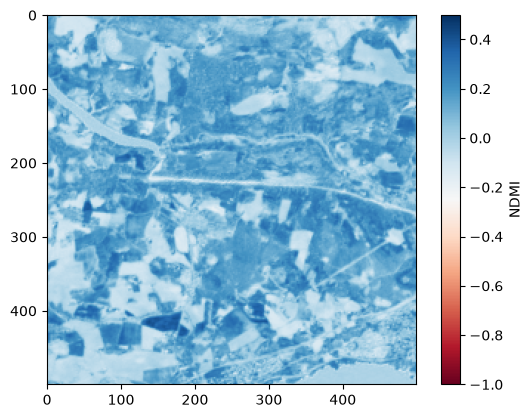

In [28]:
# Calculating Normalized Difference Moisture Index: NDMI = (NIR - SWIR) / (NIR + SWIR)
#NDMI = (da_slice[6] - da_slice[8]) / (da_slice[6] + da_slice[8])
# Calculating Normalized Difference Moisture Index: NDMI = (Green - NIR) / (Green + NIR)
NDMI = (da_slice[1] - da_slice[6]) / (da_slice[1] + da_slice[6])
# print(NDMI.min(),NDMI.max())

plt.imshow(NDMI.transpose(),cmap='RdBu', vmin=-1, vmax=0.5)
plt.colorbar(label="NDMI")

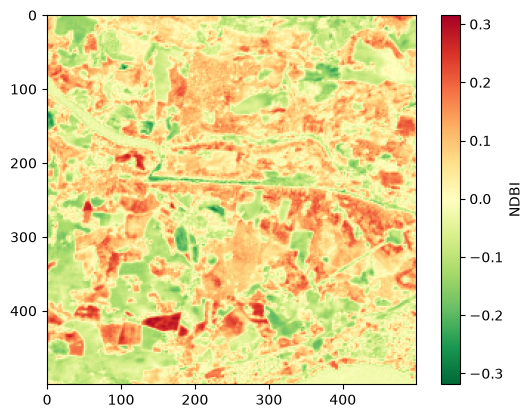

In [29]:
# Calculating Normalized Difference Buil-up Index: (SWIR2 - NIR) / (SWIR2 + NIR)
NDBI = (da_slice[9] - da_slice[6]) / (da_slice[9] + da_slice[6])
# print(NDBI.min(),NDBI.max())

plt.imshow(NDBI.transpose(), cmap='RdYlGn_r')#,vmin=-0,vmax=1)
plt.colorbar(label = "NDBI")

**Plot histogram**

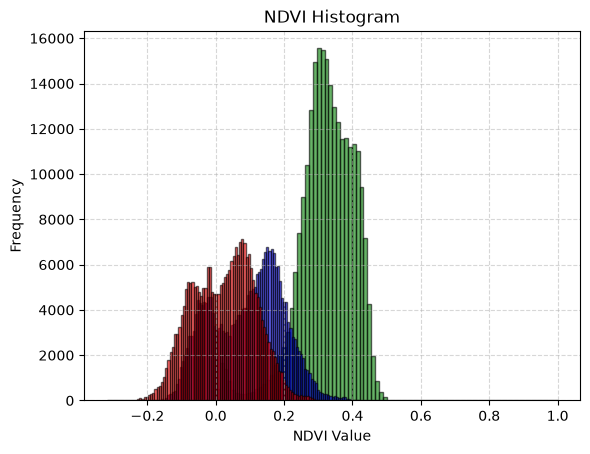

In [30]:
# Plot the histogram of three indicies together
plt.hist(NDVI.data.flatten(), bins=100, color='green', alpha=0.6, edgecolor='black')
plt.hist(NDMI.data.flatten(), bins=100, color='blue', alpha=0.6, edgecolor='black')
plt.hist(NDBI.data.flatten(), bins=100, color='red', alpha=0.6, edgecolor='black')
plt.title("NDVI Histogram")
plt.xlabel("NDVI Value")
plt.ylabel("Frequency")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [31]:
arr = np.array(da_slice[:3].load()) / 3000
histogram, bin_edges = np.histogram(arr, bins=256, range=(0, 1))

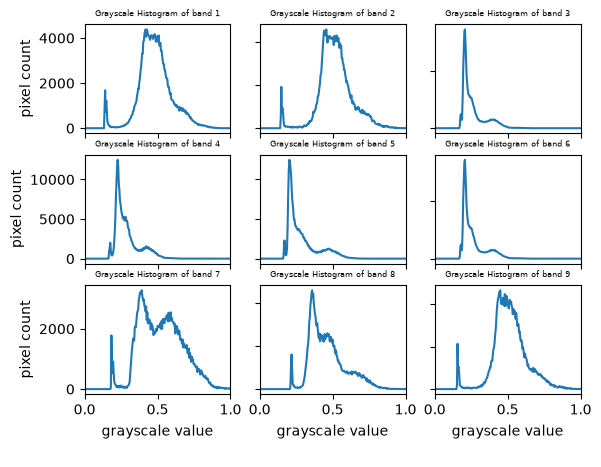

In [32]:
# Ploting the histogram of 9 out of 11 bands toghether
fig, axes = plt.subplots(3, 3)
plt.rcParams["figure.figsize"] = (30, 30)

lak = 0
for numx in range(3):
    for numy in range(3):
        arr = np.array(da_slice[lak].load())/da_slice[lak].max().data
        histogram, bin_edges = np.histogram(arr, bins=256, range=(0, 1))
        axes[numx,numy].set_title(f"Grayscale Histogram of band {lak+1}", fontsize=6)
        axes[numx,numy].set_xlabel("grayscale value\n")
        axes[numx,numy].set_ylabel("pixel count")
        axes[numx,numy].set_xlim([0.0, 1.0])  # <- named arguments do not work here
        axes[numx,numy].plot(bin_edges[0:-1], histogram)  # <- or here
        axes[numx,numy].label_outer()
        lak+=1


Note that the band number don't correspond with the acuall S2 band number

**Explore the Spatial reference system of the image using rasterio and xarray**

In [33]:
# Open the same vrt file with the use of rasterio
xds = xr.open_dataset(vrt_files[0], engine="rasterio")

In [34]:
# Two methods to get the crs of the dataet
print(xds.rio.crs)
print(xds.rio.crs.to_epsg())

EPSG:32632
32632


In [35]:
# Reprojecting the dataset. This can take some time.
xds_utm33 = xds.rio.reproject("EPSG:32633")

In [36]:
print(xds_utm33.rio.crs.crs)

AttributeError: 'rasterio.crs.CRS' object has no attribute 'crs'